# Employee & Sales Performance Analysis (SQL)

## Overview
A relational database project demonstrating SQL querying, schema design, and
business analysis using a custom-built employee/sales database.

## Objective
- Design a normalized relational schema with proper primary/foreign key relationships
- Answer real business questions using SQL (joins, aggregations, subqueries,
  window functions)
- Visualize query results to support data-driven insights

## Database Schema
- **departments**: dept_id, department, manager
- **employees**: emp_id, name, dept_id, salary, city
- **sales**: sale_id, emp_id, sale_amount, sale_month

## Methodology
1. Designed 3-table schema with foreign key relationships
2. Created tables and inserted sample data using Python + SQLite
3. Wrote business-question queries covering:
   - Joins (2-table and 3-table)
   - Aggregations (GROUP BY, HAVING)
   - Correlated subqueries (employees earning above department average)
   - Window functions (RANK employees by salary within department)
4. Visualized results using matplotlib/seaborn

## Key Business Questions Answered
- Which employees earn more than their department's average salary?
- What is the total sales per department?
- How do employees rank by salary within their department?
- Which departments exceed a sales threshold?

## Tools Used
Python, SQLite, pandas, matplotlib, seaborn

In [1]:
import sqlite3
conn = sqlite3.connect('company.db')
cursor = conn.cursor()

In [2]:
cursor.execute('''
CREATE TABLE departments (
    dept_id INTEGER PRIMARY KEY,
    department TEXT,
    manager TEXT
)
''')
conn.commit()
print('departments table is created!')

departments table is created!


In [3]:
cursor.execute('''
CREATE TABLE employees (
    emp_id INTEGER PRIMARY KEY,
    name TEXT,
    dept_id INTEGER,
    salary INTEGER,
    city TEXT,
    FOREIGN KEY (dept_id) REFERENCES departments(dept_id)
)
''')
conn.commit()
print('employees table is created!')

employees table is created!


In [4]:
cursor.execute('''
CREATE TABLE sales (
    sale_id INTEGER PRIMARY KEY,
    emp_id INTEGER,
    sale_amount INTEGER,
    sale_month TEXT,
    FOREIGN KEY (emp_id) REFERENCES employees(emp_id)
)
''')
conn.commit()
print('sales table is created!')

sales table is created!


In [5]:
cursor.executemany('''
INSERT INTO departments (dept_id, department, manager) VALUES (?,?,?)
''',[
    (1, 'Sales', 'Rohan'),
    (2, 'IT', 'Meera'),
    (3, 'HR', 'Vikram')
])
conn.commit()
print('departments data is inserted!')

departments data is inserted!


In [6]:
cursor.executemany('''
INSERT INTO employees (emp_id, name, dept_id, salary, city) VALUES (?,?,?,?,?)
''',[
    (1, 'Ravi', 1, 40000, 'Surat'),
    (2, 'Priya', 2, 60000, 'Pune'),
    (3, 'Aman', 1, 45000, 'Surat'),
    (4, 'Neha', 2, 55000, 'Mumbai'),
    (5, 'Kabir', 3, 30000, 'Pune'),
    (6, 'Sara', 1, 42000, 'Surat')
])
conn.commit()
print('employees data is inserted!')

employees data is inserted!


In [7]:
cursor.executemany('''
INSERT INTO sales (sale_id, emp_id, sale_amount, sale_month) VALUES (?,?,?,?)
''',[
    (1, 1, 15000, 'Jan'),
    (2, 1, 18000, 'Feb'),
    (3, 3, 12000, 'Jan'),
    (4, 3, 20000, 'Feb'),
    (5, 6, 16000, 'Jan'),
    (6, 6, 17000, 'Feb'),
    (7, 2, 25000, 'Jan'),
    (8, 4, 22000, 'Jan')
])
conn.commit()
print('sales data is inserted!')

sales data is inserted!


In [8]:
import pandas as pd

df_departments = pd.read_sql_query("SELECT * FROM departments", conn)
print(df_departments)

   dept_id department manager
0        1      Sales   Rohan
1        2         IT   Meera
2        3         HR  Vikram


In [9]:
df_employees = pd.read_sql_query("SELECT * FROM employees", conn)
print(df_employees)

   emp_id   name  dept_id  salary    city
0       1   Ravi        1   40000   Surat
1       2  Priya        2   60000    Pune
2       3   Aman        1   45000   Surat
3       4   Neha        2   55000  Mumbai
4       5  Kabir        3   30000    Pune
5       6   Sara        1   42000   Surat


In [10]:
df_sales = pd.read_sql_query("SELECT * FROM sales", conn)
print(df_sales)

   sale_id  emp_id  sale_amount sale_month
0        1       1        15000        Jan
1        2       1        18000        Feb
2        3       3        12000        Jan
3        4       3        20000        Feb
4        5       6        16000        Jan
5        6       6        17000        Feb
6        7       2        25000        Jan
7        8       4        22000        Jan


Show employee name, department, and manager for every employee.

In [11]:
query1 = '''
SELECT e.name, d.department, d.manager
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
'''
df_query1 = pd.read_sql_query(query1, conn)
print(df_query1)

    name department manager
0   Ravi      Sales   Rohan
1  Priya         IT   Meera
2   Aman      Sales   Rohan
3   Neha         IT   Meera
4  Kabir         HR  Vikram
5   Sara      Sales   Rohan


Find total sales amount per employee, along with their name and department.

In [12]:
query2 = '''
SELECT e.name, d.department, SUM(s.sale_amount) AS total_sales
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
JOIN sales s ON e.emp_id = s.emp_id
GROUP BY e.name, d.department
'''
df_query2 = pd.read_sql_query(query2, conn)
print(df_query2)

    name department  total_sales
0   Aman      Sales        32000
1   Neha         IT        22000
2  Priya         IT        25000
3   Ravi      Sales        33000
4   Sara      Sales        33000


Find employees who earn more than the average salary of their own department.

In [13]:
query3 = '''
SELECT e1.name, e1.salary, e1.dept_id
FROM employees e1
WHERE e1.salary > (
    SELECT AVG(e2.salary)
    FROM employees e2
    WHERE e2.dept_id = e1.dept_id
)
'''
df_query3 = pd.read_sql_query(query3, conn)
print(df_query3)

    name  salary  dept_id
0  Priya   60000        2
1   Aman   45000        1


Rank employees by salary within each department.

In [14]:
query4 = '''
SELECT name, dept_id, salary,
RANK() OVER (PARTITION BY dept_id ORDER BY salary ASC) AS salary_rank
FROM employees
'''
df_query4 = pd.read_sql_query(query4, conn)
print(df_query4)

    name  dept_id  salary  salary_rank
0   Ravi        1   40000            1
1   Sara        1   42000            2
2   Aman        1   45000            3
3   Neha        2   55000            1
4  Priya        2   60000            2
5  Kabir        3   30000            1


Find departments where total sales (across all employees) exceed 30,000.

In [15]:
query5 = '''
SELECT d.department, SUM(s.sale_amount) AS total_sales
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
JOIN sales s ON e.emp_id = s.emp_id
GROUP BY d.department
HAVING SUM(s.sale_amount) > 30000
'''
df_query5 = pd.read_sql_query(query5, conn)
print(df_query5)

  department  total_sales
0         IT        47000
1      Sales        98000


Bar chart of total sales per department

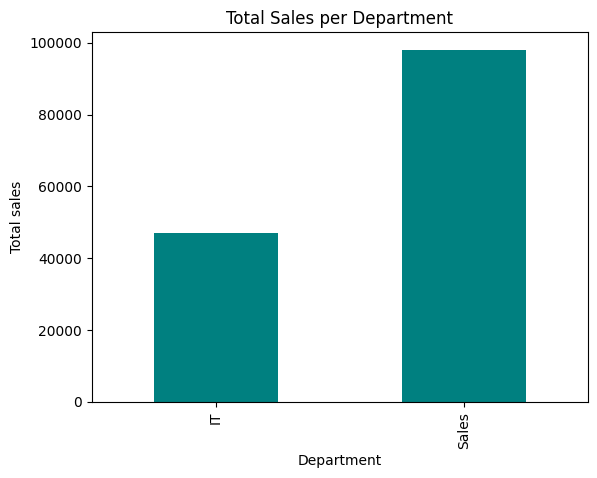

In [16]:
import matplotlib.pyplot as plt

df_query5.plot(kind='bar', x='department', y='total_sales', legend = False, color='teal')
plt.title('Total Sales per Department')
plt.xlabel('Department')
plt.ylabel('Total sales')
plt.show()

Salary comparison per employee

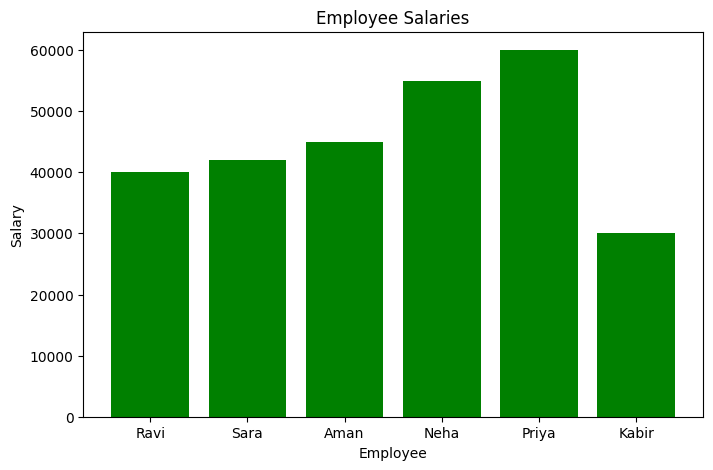

In [17]:
plt.figure(figsize=(8,5))
plt.bar(df_query4['name'], df_query4['salary'], color='green')
plt.title('Employee Salaries')
plt.xlabel('Employee')
plt.ylabel('Salary')
plt.show()

Line Chart — Sales trend by month

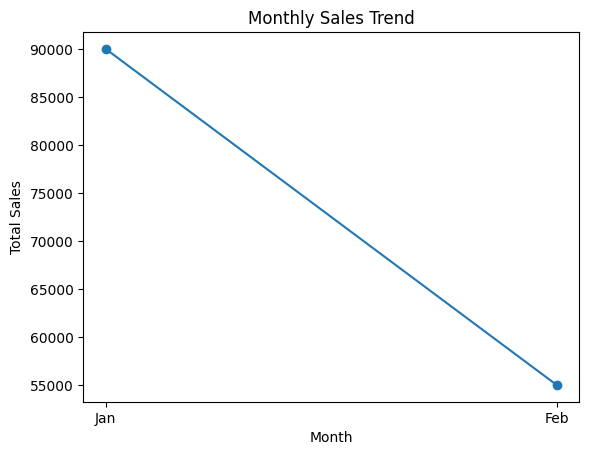

In [18]:
monthly_sales = pd.read_sql_query('''
SELECT sale_month, SUM(sale_amount) AS total
FROM sales
GROUP BY sale_month
''', conn)

month_order = ['Jan', 'Feb']
monthly_sales['sale_month'] = pd.Categorical(monthly_sales['sale_month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('sale_month')

plt.plot(monthly_sales['sale_month'], monthly_sales['total'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

Sales share by department

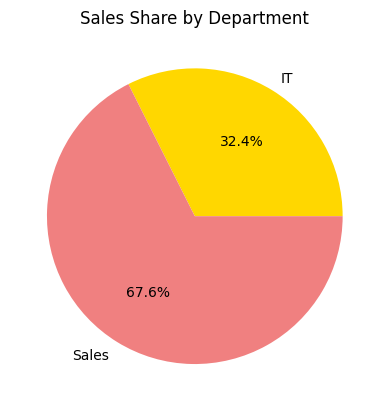

In [19]:
plt.pie(df_query5['total_sales'], labels=df_query5['department'], autopct='%1.1f%%', colors=['gold','lightcoral'])
plt.title('Sales Share by Department')
plt.show()

Salary distribution

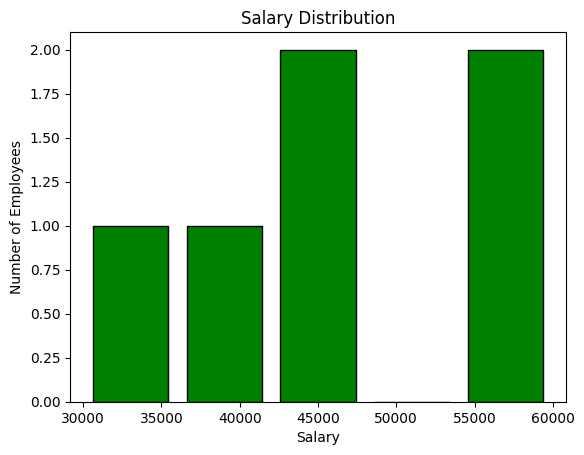

In [20]:
plt.hist(df_employees['salary'], bins=5, color='green', edgecolor='black', rwidth=0.8)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.show()

Scatter Plot — Salary vs Sale Amount

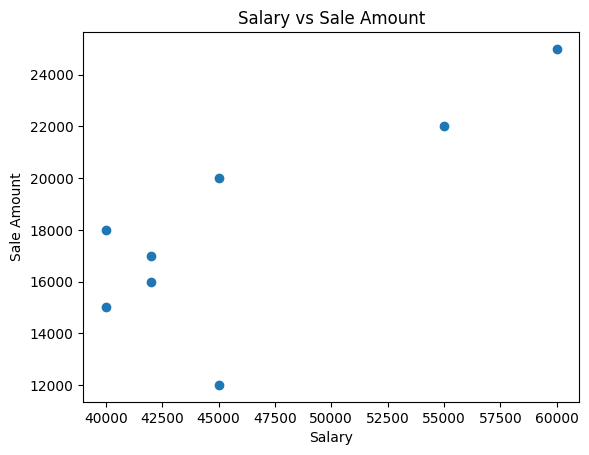

In [21]:
merged = pd.read_sql_query('''
SELECT e.name, e.salary, s.sale_amount
FROM employees e
JOIN sales s ON e.emp_id = s.emp_id
''', conn)

plt.scatter(merged['salary'], merged['sale_amount'])
plt.title('Salary vs Sale Amount')
plt.xlabel('Salary')
plt.ylabel('Sale Amount')
plt.show()

Salary spread by department

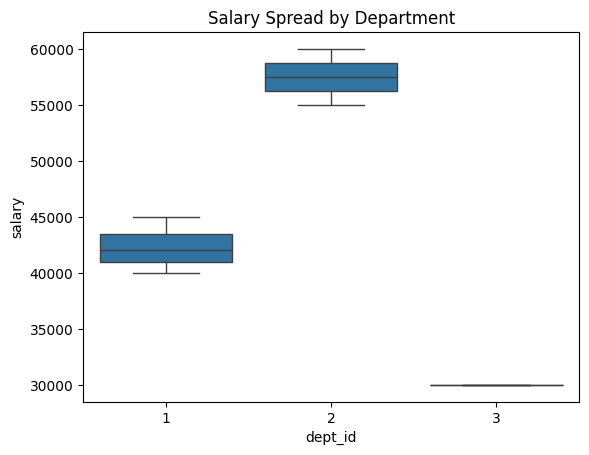

In [22]:
import seaborn as sns
sns.boxplot(x='dept_id', y='salary', data=df_employees)
plt.title('Salary Spread by Department')
plt.show()

Heatmap — Correlation between salary and sale amount

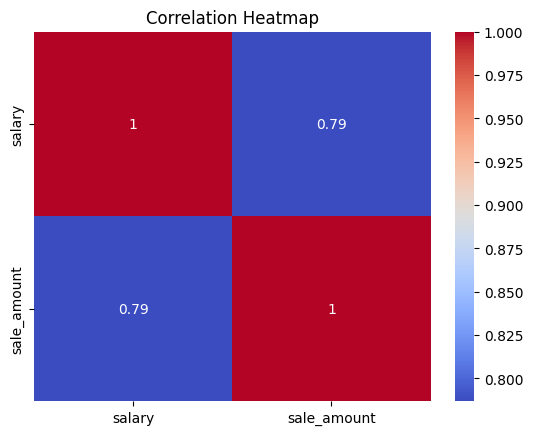

In [23]:
sns.heatmap(merged[['salary', 'sale_amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
combined = pd.read_sql_query('''
SELECT e.emp_id, e.name, e.salary, e.city, d.department, d.manager, s.sale_amount, s.sale_month
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
LEFT JOIN sales s ON e.emp_id = s.emp_id
''', conn)

combined.to_csv('company_combined.csv', index=False)

from google.colab import files
files.download('company_combined.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>